In [ ]:
import cv2
from PIL import Image

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from tqdm import tqdm
import random

from dataset import RareDataset



import cv2
import numpy as np
from tqdm import tqdm

import pandas as pd
from scipy import stats

import cv2
import numpy as np

In [ ]:
def extract_metadata(dataset):
    metadata = []

    print("Extracting image metadata...")
    for img_path, label in tqdm(dataset.samples):
        center_name = img_path.parent.parent.name

        with Image.open(img_path) as img:
            width, height = img.size

        metadata.append(
            {
                "path": str(img_path),
                "center": center_name,
                "label": label,
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
            }
        )

    return pd.DataFrame(metadata)



In [ ]:
root_path = "./RARE25-train-data"
dataset = RareDataset(root_dir=root_path)

df = extract_metadata(dataset)

Loaded dataset with 158 'neo' (neoplasia) images and 2937 'ndbe' (nondysplastic) images.
Extracting image metadata...


100%|██████████| 3095/3095 [00:09<00:00, 312.30it/s]


In [6]:
df.head()

,path,center,label,width,height,aspect_ratio
0,RARE25-train-data\center_1\neo\032d37d959444db...,center_1,neoplasia,637,512,1.244141
1,RARE25-train-data\center_1\neo\05f1b22b622640d...,center_1,neoplasia,637,512,1.244141
2,RARE25-train-data\center_1\neo\06997e0896c4490...,center_1,neoplasia,637,512,1.244141
3,RARE25-train-data\center_1\neo\0a0463f8a920413...,center_1,neoplasia,637,512,1.244141
4,RARE25-train-data\center_1\neo\0a2500f38dfa4a3...,center_1,neoplasia,310,225,1.377778


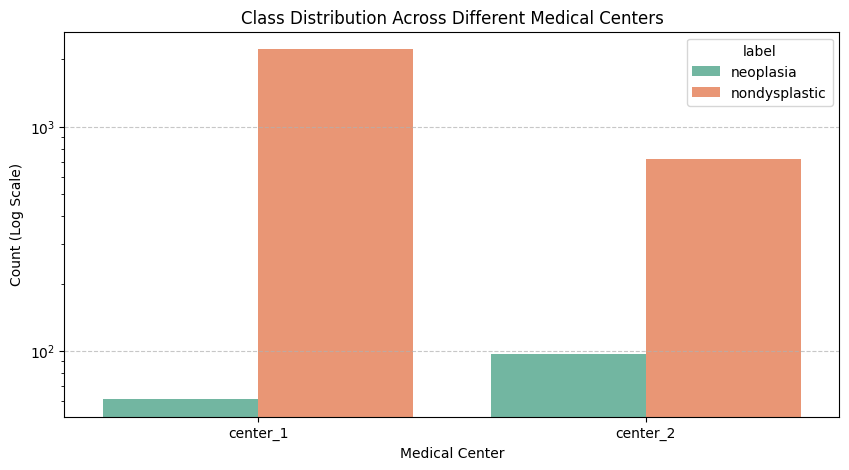

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="center", hue="label", palette="Set2")
plt.title("Class Distribution Across Different Medical Centers")
plt.xlabel("Medical Center")
plt.ylabel("Count (Log Scale)")
plt.yscale("log") 
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Observations
- Severe Imbalance: Both centers exhibit a heavy class imbalance skewed toward nondysplastic cases.

- Domain-Class Correlation: In center_1, neoplasia cases constitute a tiny fraction of the data. Conversely, center_2 contains a significantly higher proportion and absolute count of neoplasia cases.

Academic Implication
This distribution reveals a strong correlation between the domain (center) and the target label (neoplasia). A deep learning model trained on this data without regularization risks exploiting this prevalence bias, predicting the majority class of the respective center rather than learning genuine pathological features.

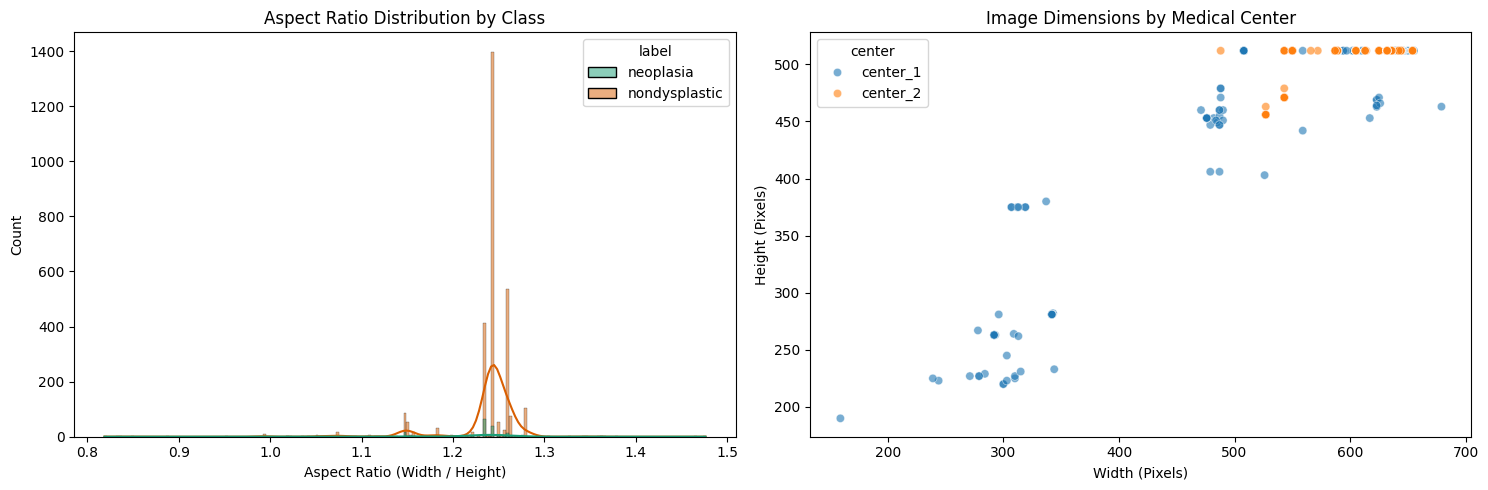

In [ ]:
def plot_geometry_analysis(df):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(
        data=df,
        x="aspect_ratio",
        hue="label",
        kde=True,
        ax=axes[0],
        palette="Dark2",
    )
    axes[0].set_title("Aspect Ratio Distribution by Class")
    axes[0].set_xlabel("Aspect Ratio (Width / Height)")

    sns.scatterplot(
        data=df,
        x="width",
        y="height", 
        hue="center",
        alpha=0.6,
        ax=axes[1],
    )
    axes[1].set_title("Image Dimensions by Medical Center")
    axes[1].set_xlabel("Width (Pixels)")
    axes[1].set_ylabel("Height (Pixels)")

    plt.tight_layout()
    plt.show()

plot_geometry_analysis(df)

Observations
- Geometric Discrepancy: center_1 exhibits high variance in image dimensions, spanning a wide range of widths (150 to 680 pixels) and heights (200 to 500 pixels).

- Fixed Hardware Signature: Images from center_2 are strictly clustered at a fixed vertical resolution (Height = 512 pixels) with tightly bounded horizontal dimensions.

- Consistent Aspect Ratio: Despite resolution differences, the aspect ratio for both domains peaks sharply around 1.25.

Academic Implication
This confirms a Structural Domain Shift. The varying resolutions indicate distinct endoscopic processors or digitization pipelines. Standardizing image inputs via resizing must be done cautiously to avoid introducing spatial distortion artifacts that the convolutional layers could exploit as shortcuts.

Analyzing color channels...


100%|██████████| 200/200 [00:00<00:00, 225.96it/s]


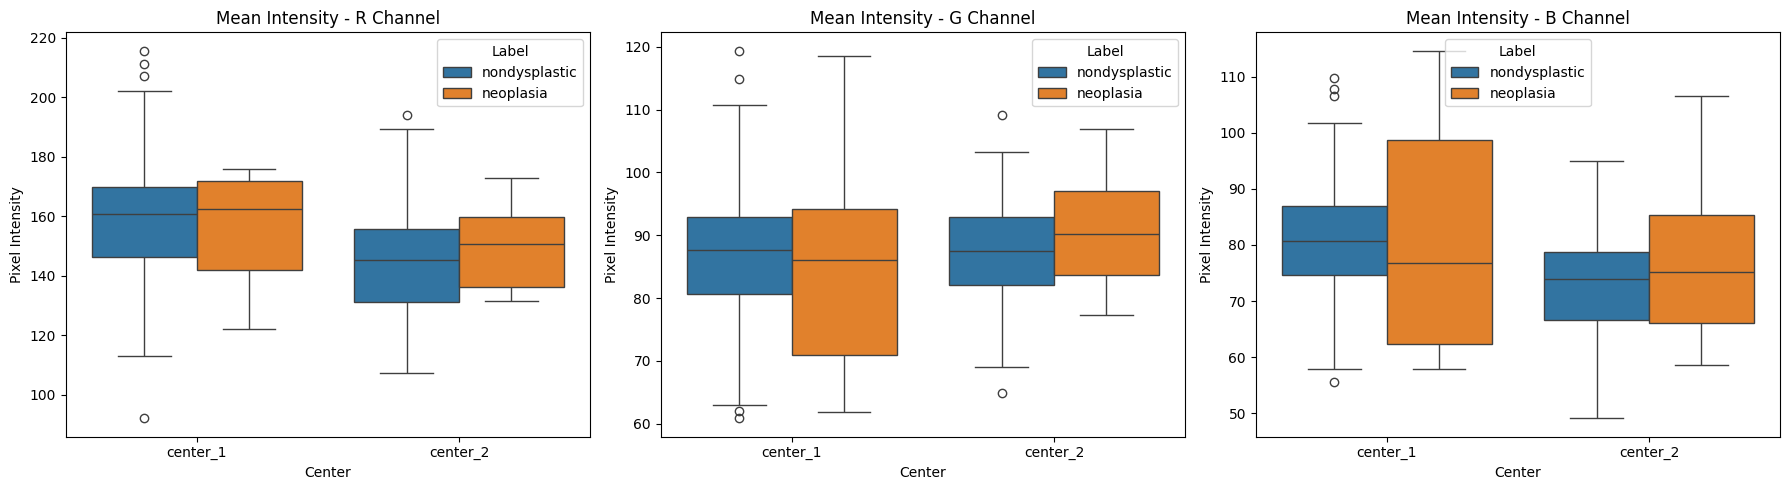

In [ ]:
def analyze_color_channels(df, num_samples=200):
    sample_df = df.sample(min(num_samples, len(df)), random_state=42)

    r_means, g_means, b_means = [], [], []
    labels, centers = [], []

    print("Analyzing color channels...")
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        img = cv2.imread(row["path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        r_means.append(np.mean(img[:, :, 0]))
        g_means.append(np.mean(img[:, :, 1]))
        b_means.append(np.mean(img[:, :, 2]))
        labels.append(row["label"])
        centers.append(row["center"])

    color_df = pd.DataFrame(
        {
            "R_Mean": r_means,
            "G_Mean": g_means,
            "B_Mean": b_means,
            "Label": labels,
            "Center": centers,
        }
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    channels = ["R_Mean", "G_Mean", "B_Mean"]
    colors = ["red", "green", "blue"]

    for i, (ch, col) in enumerate(zip(channels, colors)):
        sns.boxplot(data=color_df, x="Center", y=ch, hue="Label", ax=axes[i])
        axes[i].set_title(f"Mean Intensity - {ch.split('_')[0]} Channel")
        axes[i].set_ylabel("Pixel Intensity")

    plt.tight_layout()
    plt.show()


analyze_color_channels(df)

Observations
- R & B Channel Shift: The Red ($R$) and Blue ($B$) channels show a distinct baseline shift between the two centers; center_1 exhibits consistently higher mean intensities in both spectrums.
- G Channel Invariance: The Green ($G$) channel distributions for both centers are highly overlapping, showing nearly identical median values and variance.

Academic Implication

This identifies a Photometric Domain Shift isolated to the Red and Blue channels. This variance stems from differences in camera sensor calibration, white-balance settings, or light source technologies (e.g., Xenon vs. LED) across the clinics.

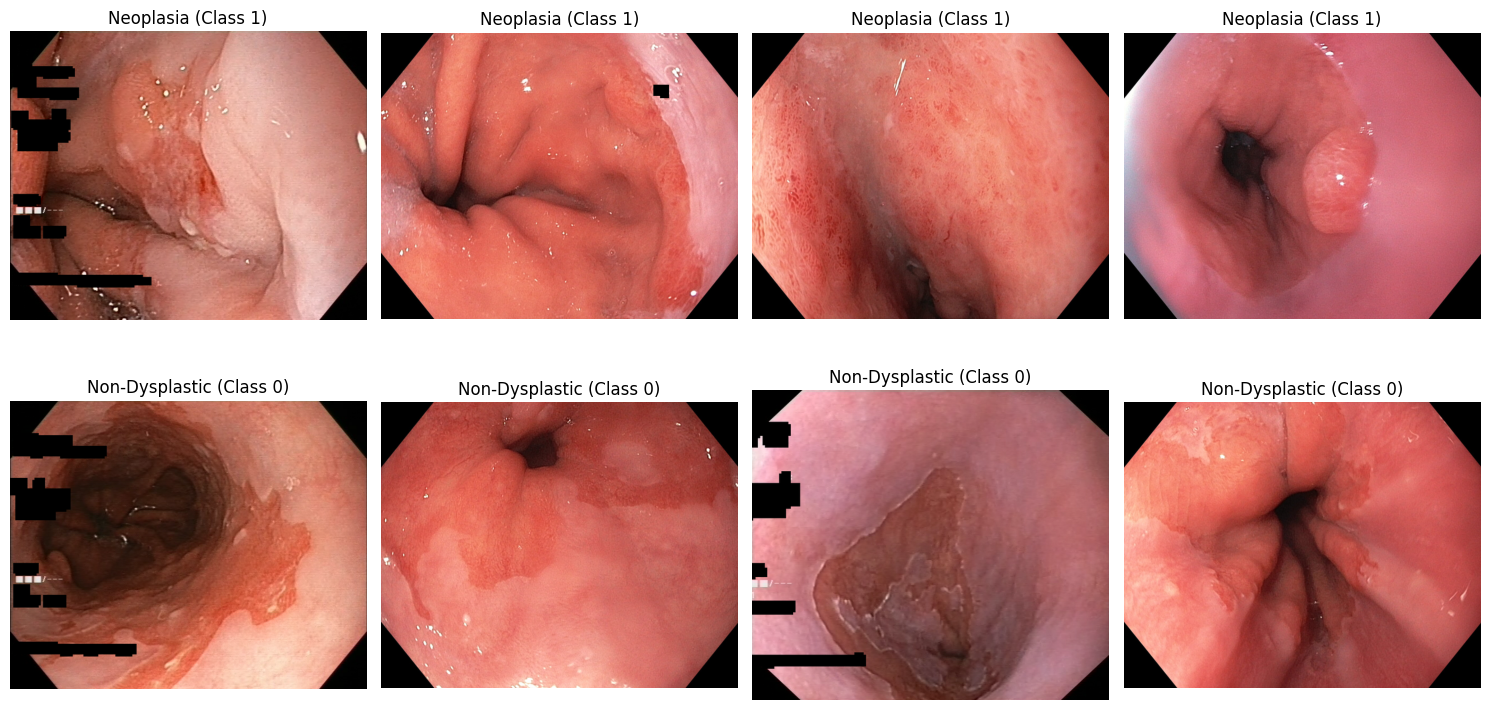

In [ ]:
def plot_sample_grid(dataset, num_samples=4):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 8))

    all_neo = [s for s in dataset.samples if s[1] == "neoplasia"]
    all_ndbe = [s for s in dataset.samples if s[1] == "nondysplastic"]

    neo_samples = random.sample(all_neo, num_samples)
    ndbe_samples = random.sample(all_ndbe, num_samples)

    for i, (path, _) in enumerate(neo_samples):
        img = Image.open(path)
        axes[0, i].imshow(img)
        axes[0, i].set_title("Neoplasia (Class 1)")
        axes[0, i].axis("off")

    for i, (path, _) in enumerate(ndbe_samples):
        img = Image.open(path)
        axes[1, i].imshow(img)
        axes[1, i].set_title("Non-Dysplastic (Class 0)")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()


plot_sample_grid(dataset)

Observations
- Images from center_2 (and specific sub-cohorts) contain prominent black-out blocks and white text labels burned directly into the left side of the frame.

- The actual tissue is framed within a non-square (octagonal/hexagonal) mask, surrounded by dead black pixels.

Academic Implication

This visual inspection confirms that the structural domain shifts caught by the statistical tests are driven by peripheral medical equipment graphics. It highlights the absolute necessity of a localized center-cropping or mask-segmentation pipeline to isolate the biological tissue (ROI) and strip away all non-clinical confounding features prior to model training.

In [ ]:
r_means, g_means, b_means = [], [], []

print("Adding color channels to the main DataFrame...")
for path in tqdm(df["path"]):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    r_means.append(np.mean(img[:, :, 0]))
    g_means.append(np.mean(img[:, :, 1]))
    b_means.append(np.mean(img[:, :, 2]))

df["R_Mean"] = r_means
df["G_Mean"] = g_means
df["B_Mean"] = b_means

print("Done! Global DataFrame 'df' is now updated with color features.")

Adding color channels to the main DataFrame...


100%|██████████| 3095/3095 [00:40<00:00, 76.07it/s] 

Done! Global DataFrame 'df' is now updated with color features.


In [ ]:
def run_statistical_tests(dataframe):
    print("=== Statistical Significance Analysis (Center 1 vs Center 2) ===")

    centers = dataframe["center"].unique()
    if len(centers) < 2:
        print("Error: You need at least two centers to compare.")
        return

    center1_data = dataframe[dataframe["center"] == centers[0]]
    center2_data = dataframe[dataframe["center"] == centers[1]]

    features = ["R_Mean", "G_Mean", "B_Mean", "aspect_ratio", "width"]

    results = []
    for feature in features:
        if feature in dataframe.columns:
            stat, p_val = stats.mannwhitneyu(
                center1_data[feature],
                center2_data[feature],
                alternative="two-sided",
            )

            is_significant = "Yes (Significant)" if p_val < 0.05 else "No"

            results.append(
                {
                    "Feature": feature,
                    "U-Statistic": stat,
                    "p-value": f"{p_val:.5e}",
                    "Significant (<0.05)": is_significant,
                }
            )

    results_df = pd.DataFrame(results)
    return results_df


results_table = run_statistical_tests(df)

results_table

=== Statistical Significance Analysis (Center 1 vs Center 2) ===


,Feature,U-Statistic,p-value,Significant (<0.05)
0,R_Mean,1226404.0,9.14209e-42,Yes (Significant)
1,G_Mean,902324.0,2.09185e-01,No
2,B_Mean,1348159.0,2.62259e-81,Yes (Significant)
3,aspect_ratio,1743834.0,0.00000e+00,Yes (Significant)
4,width,1726854.5,0.00000e+00,Yes (Significant)


Academic Implication

The non-parametric Mann-Whitney U test provides mathematical proof of the domain shift. The differences in $R$, $B$, width, and aspect_ratio are highly significant ($p \ll 0.001$). Crucially, the $G$ channel is statistically invariant ($p = 0.209$), confirming its clinical robustness. In endoscopy, the green spectrum corresponds to light absorption by hemoglobin; its consistency implies that while hardware signatures differ, the underlying biological signal remains stable.

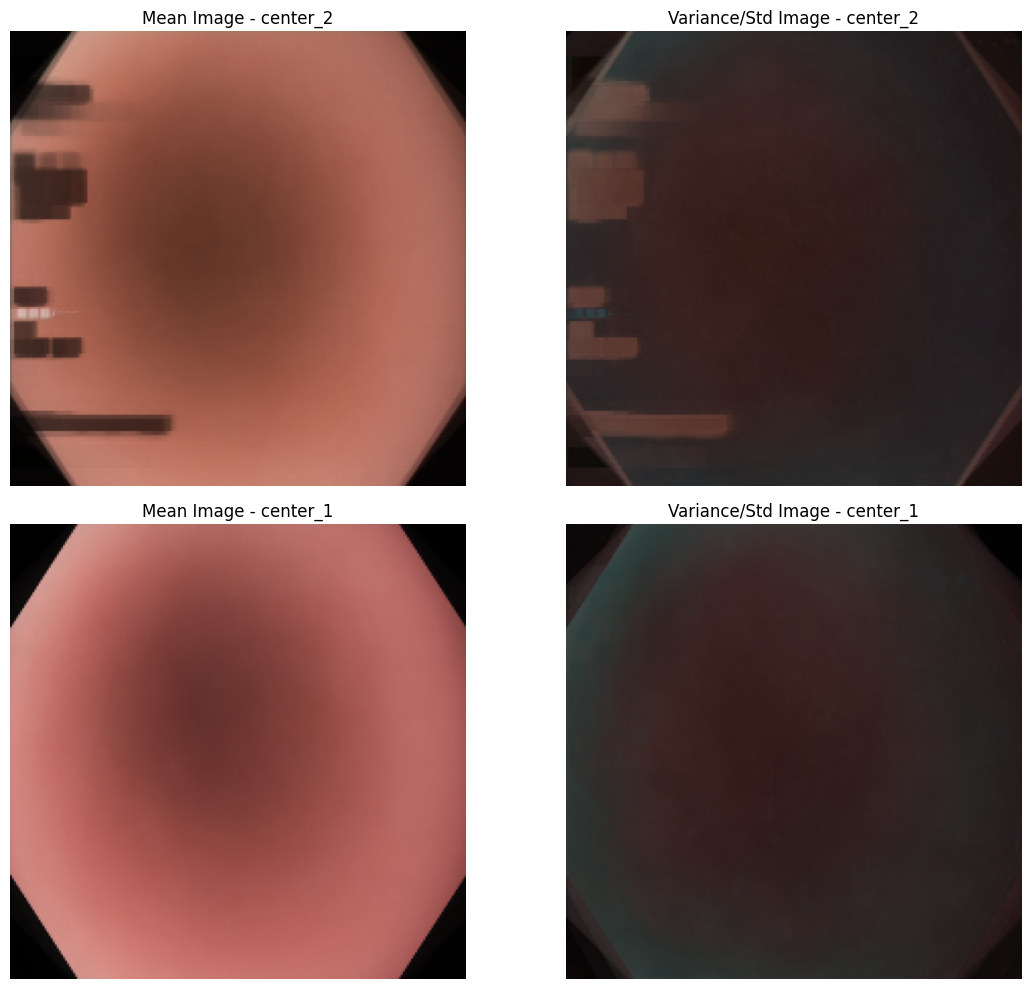

In [ ]:
def generate_domain_images(dataset, target_center, target_size=(224, 224)):
    center_samples = [
        s for s in dataset.samples if s[0].parent.parent.name == target_center
    ]

    if not center_samples:
        print(f"No samples found for center: {target_center}")
        return None, None

    num_to_process = min(200, len(center_samples))
    sampled_paths = random.sample([s[0] for s in center_samples], num_to_process)

    image_stack = []

    for img_path in sampled_paths:
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size)
        image_stack.append(img)

    image_stack = np.array(image_stack, dtype=np.float32)

    mean_image = np.mean(image_stack, axis=0) / 255.0
    std_image = np.std(image_stack, axis=0) / 255.0

    return mean_image, std_image


def plot_domain_analysis(dataset):
    centers = list(set([s[0].parent.parent.name for s in dataset.samples]))

    fig, axes = plt.subplots(len(centers), 2, figsize=(12, 5 * len(centers)))

    for idx, center in enumerate(centers):
        mean_img, std_img = generate_domain_images(dataset, center)

        if mean_img is not None:
            axes[idx, 0].imshow(mean_img)
            axes[idx, 0].set_title(f"Mean Image - {center}")
            axes[idx, 0].axis("off")

            axes[idx, 1].imshow(std_img, cmap="hot")
            axes[idx, 1].set_title(f"Variance/Std Image - {center}")
            axes[idx, 1].axis("off")

    plt.tight_layout()
    plt.show()


plot_domain_analysis(dataset)

Observations
- UI Artifact Injection: The Mean and Variance/Std images for center_2 reveal distinct, high-contrast structural artifacts (text overlays, patient metadata brackets, and software borders) on the left-hand margin.

- Homogeneous Baseline: center_1 projections display a clean, unobstructed hexagonal endoscopic field of view (FOV) with zero peripheral artifacts.

Academic Implication

This is a critical finding demonstrating a Confounding Variable (Clever Hans Effect). Because center_2 has a higher rate of neoplasia, a neural network will likely learn to recognize the presence of the left-side text/UI elements as a proxy shortcut for a positive diagnosis, entirely bypassing the clinical tissue pathology.